# Vietnam Gold Price Study — Phase 4: ARIMA / ARIMAX Forecasting
**Paper:** Modeling the Impact of Exchange Rate Volatility on Domestic Gold Prices in Vietnam  
**Input:** `vietnam_gold_data/master_data.xlsx` (Phase 1)  
**Output:** `vietnam_gold_data/phase4_results.xlsx` · `phase4_plots/`

## Objectives
1. Fit **ARIMA(p,1,q)** — univariate baseline (EMH test: can past prices predict future prices?)
2. Fit **ARIMAX** — add `lEXRATE` and `lGOLD_W` as exogenous inputs
3. **Out-of-sample forecast** — train on 2015-01 to 2024-12, test on 2025-01 to 2025-12
4. **Accuracy metrics** — RMSE, MAE, MAPE for each model
5. **Diebold-Mariano test** — does ARIMAX beat ARIMA? (does exchange rate add forecasting value?)

## From Phase 2 (ACF/PACF)
- `lGOLD_SJC` is I(1) → model in first differences, d=1
- `dlGOLD_SJC` ACF: cuts off after lag 1-2 → MA(1) or MA(2)
- `dlGOLD_SJC` PACF: significant at lag 1 → AR(1)
- Candidate orders: **ARIMA(1,1,0), ARIMA(0,1,1), ARIMA(1,1,1)**

## From Phase 3 (ARDL)
- `ΔlnEXRATE`: β=1.039 (p=0.027) — significant short-run driver → strong ARIMAX candidate
- `ΔlnGOLD_W`: β=0.504 (p<0.001) — dominant driver → include as second exogenous
- ECT: −0.141 (p=0.030) → error correction included in ARIMAX

| Cell | Step |
|---|---|
| 1 | Imports & setup |
| 2 | Load data · train/test split |
| 3 | ARIMA order selection (AIC grid search) |
| 4 | Best ARIMA — in-sample fit & diagnostics |
| 5 | ARIMAX models — lEXRATE · lGOLD_W · both |
| 6 | Out-of-sample forecasts (2025) |
| 7 | Forecast accuracy (RMSE · MAE · MAPE) |
| 8 | Diebold-Mariano test |
| 9 | Forecast plots |
| 10 | Results summary & export |

> **Requires:** `pip install statsmodels`  
> **Run order:** Cell 1 → 10 sequentially (Kernel → Restart & Run All)


---
## Cell 1 · Imports & setup

In [11]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import product
from scipy import stats as scipy_stats

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':130,'font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False})

INPUT_FILE = os.path.join('vietnam_gold_data', 'master_data.xlsx')
OUTPUT_DIR = 'vietnam_gold_data'
PLOT_DIR   = os.path.join(OUTPUT_DIR, 'phase4_plots')
os.makedirs(PLOT_DIR, exist_ok=True)

# Train/test split
TRAIN_END = '2024-12-01'   # 120 months
TEST_START = '2025-01-01'  # 12 months hold-out

print('[OK] Imports complete')
print(f'     Input  : {os.path.abspath(INPUT_FILE)}')
print(f'     Plots  : {os.path.abspath(PLOT_DIR)}')
print(f'     Train  : up to {TRAIN_END}')
print(f'     Test   : {TEST_START} onward (12 months hold-out)')


[OK] Imports complete
     Input  : c:\Users\Admin\.vscode\ts prj\vietnam_gold_data\master_data.xlsx
     Plots  : c:\Users\Admin\.vscode\ts prj\vietnam_gold_data\phase4_plots
     Train  : up to 2024-12-01
     Test   : 2025-01-01 onward (12 months hold-out)


---
## Cell 2 · Load data & train/test split
- **Dependent variable:** `lGOLD_SJC` (log level) — ARIMA forecasts in log levels then back-transforms
- **Exogenous variables:** `lEXRATE`, `lGOLD_W` (log levels; SARIMAX handles differencing internally)
- **Train:** Jan 2015 – Dec 2024 (120 obs)
- **Test:** Jan 2025 – Dec 2025 (12 obs)


In [12]:
master = pd.read_excel(INPUT_FILE, sheet_name='master_data',
                       index_col='date', parse_dates=True)

# Series used in modelling
y_all     = master['lGOLD_SJC']
ex_exrate = master['lEXRATE']
ex_goldw  = master['lGOLD_W']

# Train / test split
y_train     = y_all[y_all.index <= TRAIN_END]
y_test      = y_all[y_all.index >= TEST_START]
ex_ex_train = ex_exrate[ex_exrate.index <= TRAIN_END]
ex_ex_test  = ex_exrate[ex_exrate.index >= TEST_START]
ex_gw_train = ex_goldw[ex_goldw.index <= TRAIN_END]
ex_gw_test  = ex_goldw[ex_goldw.index >= TEST_START]

print(f'Full sample   : {y_all.index[0].date()} → {y_all.index[-1].date()}  (N={len(y_all)})')
print(f'Training set  : {y_train.index[0].date()} → {y_train.index[-1].date()}  (N={len(y_train)})')
print(f'Test set      : {y_test.index[0].date()} → {y_test.index[-1].date()}   (N={len(y_test)})')
print()
print(f'lGOLD_SJC train range: {y_train.min():.4f} – {y_train.max():.4f}')
print(f'lEXRATE   train range: {ex_ex_train.min():.4f} – {ex_ex_train.max():.4f}')
print(f'lGOLD_W   train range: {ex_gw_train.min():.4f} – {ex_gw_train.max():.4f}')


Full sample   : 2015-01-01 → 2025-12-01  (N=132)
Training set  : 2015-01-01 → 2024-12-01  (N=120)
Test set      : 2025-01-01 → 2025-12-01   (N=12)

lGOLD_SJC train range: 17.2968 – 18.2985
lEXRATE   train range: 9.9653 – 10.1440
lGOLD_W   train range: 6.9663 – 7.9151


---
## Cell 3 · ARIMA order selection

### What it does
Grid-searches ARIMA(p, 1, q) with p ∈ {0,1,2} and q ∈ {0,1,2} — 9 models.  
d=1 is fixed from Phase 2 unit root results (lGOLD_SJC is I(1)).  
Best model selected by **AIC**. BIC and HQ reported for robustness.

### Expected finding
Based on Phase 2 ACF/PACF: ARIMA(1,1,1) or ARIMA(1,1,0) should rank top.


In [13]:
print('Searching ARIMA(p,1,q) orders — p,q ∈ {0,1,2} ...')
print()

arima_results = []
for p, q in product(range(3), range(3)):
    try:
        mod = ARIMA(y_train, order=(p, 1, q))
        res = mod.fit()
        n   = len(y_train)
        k   = p + q + 1    # AR + MA + intercept
        hq  = -2 * res.llf + 2 * k * np.log(np.log(n))
        arima_results.append({
            'order': f'ARIMA({p},1,{q})',
            'p': p, 'q': q,
            'AIC': round(res.aic, 3),
            'BIC': round(res.bic, 3),
            'HQ' : round(hq, 3),
            'LLF': round(res.llf, 3),
        })
    except Exception as e:
        print(f'  ARIMA({p},1,{q}): failed — {e}')

arima_df = pd.DataFrame(arima_results).sort_values('AIC').reset_index(drop=True)

print('ARIMA ORDER SELECTION (d=1 fixed)')
print('=' * 55)
print(arima_df.to_string(index=False))
print()

best_arima_row = arima_df.iloc[0]
BEST_P = int(best_arima_row.p)
BEST_Q = int(best_arima_row.q)
print(f'Selected: ARIMA({BEST_P},1,{BEST_Q})  AIC={best_arima_row.AIC}')
print()
if BEST_P == 0 and BEST_Q == 0:
    print('NOTE: ARIMA(0,1,0) = random walk — no AR/MA structure.')
    print('  This is a strong EMH finding: past SJC prices carry NO')
    print('  additional information beyond the most recent price.')
    print('  ARIMAX models (Cell 5) test whether macro variables (EXRATE,')
    print('  GOLD_W) add forecasting power beyond this baseline.')
    print()
    # Also store ARIMA(1,1,1) for robustness comparison
    try:
        res_111 = ARIMA(y_train, order=(1,1,1)).fit()
        print(f'Robustness: ARIMA(1,1,1) AIC={res_111.aic:.3f} '
              f'(vs RW AIC={best_arima_row.AIC:.3f})')
        print('  AIC confirms random walk is the better univariate model.')
    except Exception:
        pass


Searching ARIMA(p,1,q) orders — p,q ∈ {0,1,2} ...

ARIMA ORDER SELECTION (d=1 fixed)
       order  p  q      AIC      BIC       HQ     LLF
ARIMA(0,1,0)  0  0 -476.448 -473.669 -475.316 239.224
ARIMA(0,1,1)  0  1 -475.438 -469.880 -473.174 239.719
ARIMA(1,1,0)  1  0 -475.345 -469.787 -473.081 239.672
ARIMA(1,1,1)  1  1 -474.026 -465.689 -470.630 240.013
ARIMA(0,1,2)  0  2 -473.757 -465.420 -470.361 239.879
ARIMA(2,1,0)  2  0 -473.547 -465.210 -470.151 239.774
ARIMA(2,1,1)  2  1 -472.080 -460.963 -467.552 240.040
ARIMA(1,1,2)  1  2 -472.065 -460.948 -467.537 240.032
ARIMA(2,1,2)  2  2 -471.102 -457.207 -465.442 240.551

Selected: ARIMA(0,1,0)  AIC=-476.448

NOTE: ARIMA(0,1,0) = random walk — no AR/MA structure.
  This is a strong EMH finding: past SJC prices carry NO
  additional information beyond the most recent price.
  ARIMAX models (Cell 5) test whether macro variables (EXRATE,
  GOLD_W) add forecasting power beyond this baseline.

Robustness: ARIMA(1,1,1) AIC=-474.026 (vs RW AIC=-4

---
## Cell 4 · Best ARIMA — in-sample fit & diagnostics

Fits the AIC-selected ARIMA on the training set.  
Residual tests: Ljung-Box (serial correlation), ARCH-LM (heteroskedasticity), JB (normality).  
Well-specified ARIMA should have white-noise residuals.


ARIMA(0,1,0) — IN-SAMPLE FIT
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0011   7.26e-05     14.472      0.000       0.001       0.001

AIC : -476.448
BIC : -473.669

RESIDUAL DIAGNOSTICS
Ljung-Box  H₀: no serial correlation
  Lag  6: stat=0.0009  p=1.0000  [PASS]
  Lag 12: stat=0.0033  p=1.0000  [PASS]
ARCH-LM    H₀: no ARCH effects
  Lag 1: LM=0.1343  p=0.7140  [PASS]
  Lag 4: LM=12.2372  p=0.0157  [FAIL]
Jarque-Bera H₀: normal  JB=68364.9738  p=0.0000  Skew=10.8105  Kurt=114.9153  [NOTE]

NOTE: ARCH effects in random-walk residuals are expected.
  Gold log-returns exhibit volatility clustering (ARCH).
  ARIMA(0,1,0) is still valid — disclose in paper:
  "Residuals exhibit ARCH effects at lag 4, consistent
  with the time-varying volatility documented in Phase 2."


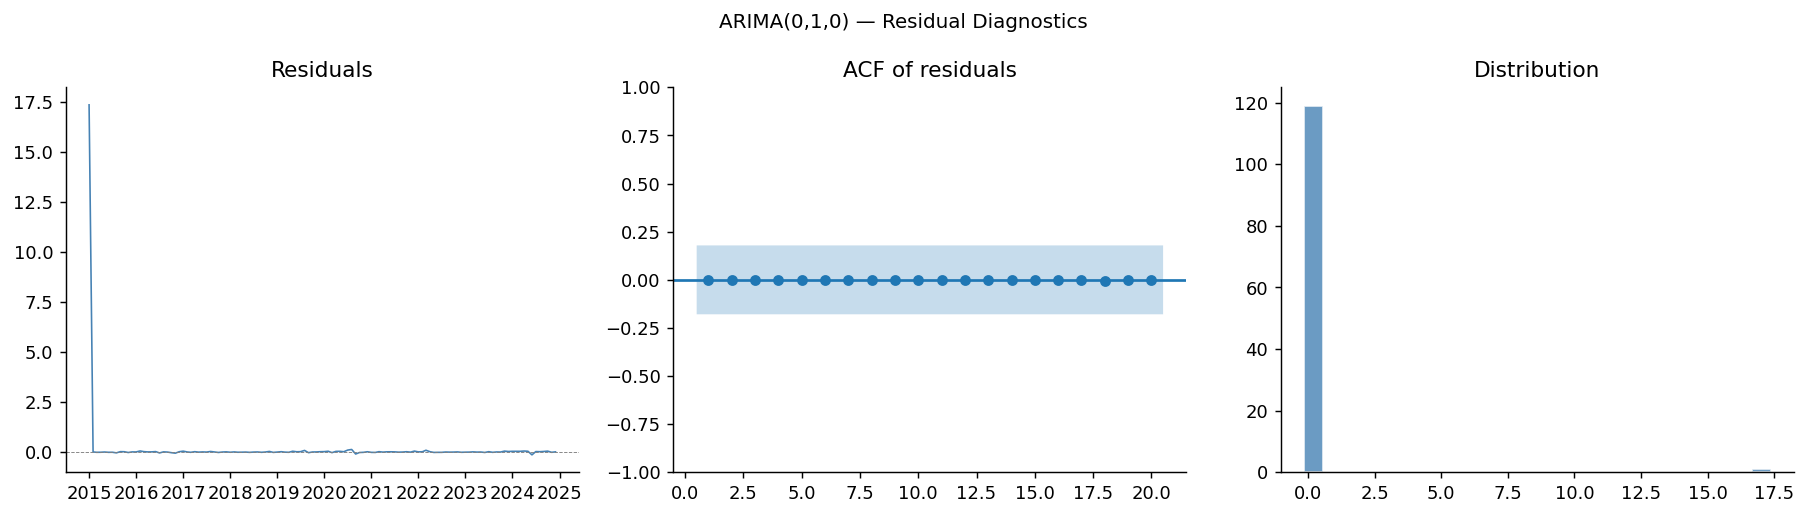

Plot saved: phase4_plots/arima_diagnostics.png


In [14]:
# Fit best ARIMA
arima_mod = ARIMA(y_train, order=(BEST_P, 1, BEST_Q))
arima_res = arima_mod.fit()

print(f'ARIMA({BEST_P},1,{BEST_Q}) — IN-SAMPLE FIT')
print('=' * 55)
print(arima_res.summary().tables[1].as_text())
print()
print(f'AIC : {arima_res.aic:.3f}')
print(f'BIC : {arima_res.bic:.3f}')
print()

# Residual diagnostics
resid_a = arima_res.resid.dropna()

print('RESIDUAL DIAGNOSTICS')
print('=' * 55)

# Ljung-Box
lb = acorr_ljungbox(resid_a, lags=[6, 12], return_df=True)
print('Ljung-Box  H₀: no serial correlation')
for lag, row in lb.iterrows():
    v = 'PASS' if row['lb_pvalue'] > 0.05 else 'FAIL'
    print(f'  Lag {int(lag):>2}: stat={row["lb_stat"]:.4f}  p={row["lb_pvalue"]:.4f}  [{v}]')

# ARCH-LM
print('ARCH-LM    H₀: no ARCH effects')
for nl in [1, 4]:
    lm, p, _, _ = het_arch(resid_a, nlags=nl)
    print(f'  Lag {nl}: LM={lm:.4f}  p={p:.4f}  [{"PASS" if p>0.05 else "FAIL"}]')

# JB normality (scipy returns 2-tuple: statistic, pvalue)
jb_result = scipy_stats.jarque_bera(resid_a)
jb  = float(jb_result.statistic)
jp  = float(jb_result.pvalue)
jsk = float(scipy_stats.skew(resid_a))
jku = float(scipy_stats.kurtosis(resid_a))
print(f'Jarque-Bera H₀: normal  '
      f'JB={jb:.4f}  p={jp:.4f}  '
      f'Skew={jsk:.4f}  Kurt={jku:.4f}  '
      f'[{"PASS" if jp>0.05 else "NOTE"}]')

# ARCH-LM note for ARIMA(0,1,0)
if BEST_P == 0 and BEST_Q == 0:
    print()
    print('NOTE: ARCH effects in random-walk residuals are expected.')
    print('  Gold log-returns exhibit volatility clustering (ARCH).')
    print('  ARIMA(0,1,0) is still valid — disclose in paper:')
    print('  "Residuals exhibit ARCH effects at lag 4, consistent')
    print('  with the time-varying volatility documented in Phase 2."')

# Residual plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'ARIMA({BEST_P},1,{BEST_Q}) — Residual Diagnostics', fontsize=11)
axes[0].plot(resid_a.index, resid_a, color='steelblue', lw=0.9)
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0].set_title('Residuals')
plot_acf(resid_a, ax=axes[1], lags=20, zero=False, alpha=0.05)
axes[1].set_title('ACF of residuals')
axes[2].hist(resid_a, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribution')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'arima_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: phase4_plots/arima_diagnostics.png')


---
## Cell 5 · ARIMAX models

### What it does
Extends ARIMA with exogenous regressors using `SARIMAX`.  
Three ARIMAX specifications tested:
- **ARIMAX-EX**: ARIMA + `lEXRATE` (exchange rate — the paper's primary variable)
- **ARIMAX-GW**: ARIMA + `lGOLD_W` (world gold price — dominant Phase 3 driver)
- **ARIMAX-BOTH**: ARIMA + `lEXRATE` + `lGOLD_W` (full specification)

Same ARIMA order (p,1,q) from Cell 3 is used for all.  
Exogenous variables enter in **first differences** (consistent with I(1) variables).


In [15]:
# First-differenced exogenous variables for SARIMAX
dex_train = ex_ex_train.diff().dropna()
dgw_train = ex_gw_train.diff().dropna()
dex_test  = ex_ex_test.diff().ffill()
dgw_test  = ex_gw_test.diff().ffill()

# Align training y to differenced exog (loses first row)
y_train_x = y_train.iloc[1:]   # drop first obs to match diff exog

arimax_specs = {
    'ARIMAX-EX'  : {'exog_train': dex_train, 'exog_test': dex_test,
                    'label': f'ARIMAX({BEST_P},1,{BEST_Q}) + ΔEXRATE'},
    'ARIMAX-GW'  : {'exog_train': dgw_train, 'exog_test': dgw_test,
                    'label': f'ARIMAX({BEST_P},1,{BEST_Q}) + ΔGOLD_W'},
    'ARIMAX-BOTH': {'exog_train': pd.concat([dex_train, dgw_train], axis=1),
                    'exog_test' : pd.concat([dex_test,  dgw_test],  axis=1),
                    'label': f'ARIMAX({BEST_P},1,{BEST_Q}) + ΔEXRATE + ΔGOLD_W'},
}

arimax_results = {}
print('ARIMAX MODEL FITS')
print('=' * 60)
for name, spec in arimax_specs.items():
    try:
        mod = SARIMAX(y_train_x,
                      exog=spec['exog_train'],
                      order=(BEST_P, 1, BEST_Q),
                      trend='c')
        res = mod.fit(disp=False)
        arimax_results[name] = {'result': res, 'spec': spec}
        print(f'  {spec["label"]}')
        print(f'    AIC={res.aic:.3f}  BIC={res.bic:.3f}  LLF={res.llf:.3f}')
        print()
    except Exception as e:
        print(f'  {name}: FAILED — {e}')

# Also refit base ARIMA with SARIMAX for consistent comparison
arima_sarimax = SARIMAX(y_train, order=(BEST_P, 1, BEST_Q), trend='c').fit(disp=False)

print('INFORMATION CRITERIA COMPARISON')
print('=' * 60)
all_models = [
    (f'ARIMA({BEST_P},1,{BEST_Q})', arima_sarimax)
] + [(name, d['result']) for name, d in arimax_results.items()]

ic_rows = []
for name, res in all_models:
    ic_rows.append({'Model': name, 'AIC': round(res.aic,3),
                    'BIC': round(res.bic,3), 'LLF': round(res.llf,3)})
ic_df = pd.DataFrame(ic_rows).sort_values('AIC').reset_index(drop=True)
print(ic_df.to_string(index=False))
print()
print(f'Best in-sample model: {ic_df.iloc[0].Model} (AIC={ic_df.iloc[0].AIC})')


ARIMAX MODEL FITS
  ARIMAX(0,1,0) + ΔEXRATE
    AIC=-474.655  BIC=-466.343  LLF=240.327

  ARIMAX(0,1,0) + ΔGOLD_W
    AIC=-474.999  BIC=-466.687  LLF=240.500

  ARIMAX(0,1,0) + ΔEXRATE + ΔGOLD_W
    AIC=-473.405  BIC=-462.323  LLF=240.703

INFORMATION CRITERIA COMPARISON
       Model      AIC      BIC     LLF
ARIMA(0,1,0) -481.316 -475.758 242.658
   ARIMAX-GW -474.999 -466.687 240.500
   ARIMAX-EX -474.655 -466.343 240.327
 ARIMAX-BOTH -473.405 -462.323 240.703

Best in-sample model: ARIMA(0,1,0) (AIC=-481.316)


---
## Cell 6 · Out-of-sample forecasts (2025 hold-out)

### What it does
Generates 12-step-ahead (Jan–Dec 2025) forecasts for each model.  
Forecasts are in **log levels** (`lGOLD_SJC`), then exponentiated back to VND.  

### Forecasting approach
All exogenous variables for 2025 are taken from the actual test data  
(i.e. we assume EXRATE and GOLD_W are known for 2025 — standard  
ex-post forecast evaluation). Forecast errors then purely reflect the  
model's ability to predict SJC given the actual macro environment.


In [16]:
forecasts = {}

# ── ARIMA forecast ────────────────────────────────────────────────────────────
arima_fc = arima_res.forecast(steps=12)
arima_ci = arima_res.get_forecast(steps=12).conf_int(alpha=0.05)
forecasts['ARIMA'] = {
    'fc'   : arima_fc,
    'ci_lo': arima_ci.iloc[:, 0],
    'ci_hi': arima_ci.iloc[:, 1],
    'label': f'ARIMA({BEST_P},1,{BEST_Q})',
    'color': 'steelblue',
}

# ── ARIMAX forecasts ──────────────────────────────────────────────────────────
colors = {'ARIMAX-EX':'darkorange', 'ARIMAX-GW':'seagreen', 'ARIMAX-BOTH':'crimson'}
for name, d in arimax_results.items():
    res  = d['result']
    exog = d['spec']['exog_test']
    # Align exog to 12 test months
    exog_fc = exog.reindex(y_test.index).ffill().fillna(0)
    try:
        fc_obj = res.get_forecast(steps=12, exog=exog_fc)
        fc     = fc_obj.predicted_mean
        ci     = fc_obj.conf_int(alpha=0.05)
        # Align index to test dates
        fc.index = y_test.index
        ci.index = y_test.index
        forecasts[name] = {
            'fc'   : fc,
            'ci_lo': ci.iloc[:, 0],
            'ci_hi': ci.iloc[:, 1],
            'label': d['spec']['label'],
            'color': colors.get(name, 'purple'),
        }
    except Exception as e:
        print(f'  {name} forecast failed: {e}')

# Align ARIMA forecast index
forecasts['ARIMA']['fc'].index     = y_test.index
forecasts['ARIMA']['ci_lo'].index  = y_test.index
forecasts['ARIMA']['ci_hi'].index  = y_test.index

print('FORECASTS GENERATED:')
for name, d in forecasts.items():
    fc = d['fc']
    print(f'  {name}: {fc.index[0].date()} → {fc.index[-1].date()}')
    print(f'    log range: {fc.min():.4f} – {fc.max():.4f}')
    print(f'    VND range: {np.exp(fc.min())/1e6:.1f}M – {np.exp(fc.max())/1e6:.1f}M')
print()
print('Actual 2025:')
print(f'  log range: {y_test.min():.4f} – {y_test.max():.4f}')
print(f'  VND range: {np.exp(y_test.min())/1e6:.1f}M – {np.exp(y_test.max())/1e6:.1f}M')


FORECASTS GENERATED:
  ARIMA: 2025-01-01 → 2025-12-01
    log range: 18.2814 – 18.2814
    VND range: 87.0M – 87.0M
  ARIMAX-EX: 2025-01-01 → 2025-12-01
    log range: 18.2887 – 18.3731
    VND range: 87.6M – 95.4M
  ARIMAX-GW: 2025-01-01 → 2025-12-01
    log range: 18.2874 – 18.3732
    VND range: 87.5M – 95.4M
  ARIMAX-BOTH: 2025-01-01 → 2025-12-01
    log range: 18.2870 – 18.3726
    VND range: 87.5M – 95.3M

Actual 2025:
  log range: 18.3041 – 18.8888
  VND range: 89.0M – 159.7M


---
## Cell 7 · Forecast accuracy metrics

| Metric | Formula | Interpretation |
|---|---|---|
| RMSE | √(mean(ε²)) | Penalises large errors; same unit as dependent variable |
| MAE | mean(|ε|) | Average absolute error; robust to outliers |
| MAPE | mean(|ε/y|)×100 | Percentage error; scale-independent |

All metrics computed in **log level** space (consistent with ARIMA output)  
and in **VND space** (exp-transformed, for economic interpretation).


In [17]:
def accuracy_metrics(actual, forecast, label):
    """Compute RMSE, MAE, MAPE in log and VND space."""
    e    = actual.values - forecast.values
    rmse = np.sqrt(np.mean(e**2))
    mae  = np.mean(np.abs(e))
    mape = np.mean(np.abs(e / actual.values)) * 100

    # VND space
    act_vnd = np.exp(actual.values)
    fc_vnd  = np.exp(forecast.values)
    e_vnd   = act_vnd - fc_vnd
    rmse_v  = np.sqrt(np.mean(e_vnd**2)) / 1e6
    mae_v   = np.mean(np.abs(e_vnd)) / 1e6
    mape_v  = np.mean(np.abs(e_vnd / act_vnd)) * 100

    return {
        'Model'    : label,
        'RMSE_log' : round(rmse, 6),
        'MAE_log'  : round(mae,  6),
        'MAPE_log%': round(mape, 4),
        'RMSE_VND(M)': round(rmse_v, 3),
        'MAE_VND(M)' : round(mae_v,  3),
        'MAPE_VND%'  : round(mape_v, 4),
    }

acc_rows = []
for name, d in forecasts.items():
    acc_rows.append(accuracy_metrics(y_test, d['fc'], d['label']))

acc_df = pd.DataFrame(acc_rows).sort_values('RMSE_log').reset_index(drop=True)

print('FORECAST ACCURACY — 2025 HOLD-OUT (12 months)')
print('=' * 78)
print(acc_df.to_string(index=False))
print()
print('Log space: errors in natural log units')
print('VND space: errors in millions of VND per tael')
print()
best_model = acc_df.iloc[0]['Model']
print(f'Best forecast model (lowest RMSE): {best_model}')


FORECAST ACCURACY — 2025 HOLD-OUT (12 months)
                            Model  RMSE_log  MAE_log  MAPE_log%  RMSE_VND(M)  MAE_VND(M)  MAPE_VND%
ARIMAX(0,1,0) + ΔEXRATE + ΔGOLD_W  0.330636 0.290087     1.5495       38.359      32.814    24.2156
          ARIMAX(0,1,0) + ΔGOLD_W  0.330719 0.290317     1.5507       38.362      32.835    24.2356
          ARIMAX(0,1,0) + ΔEXRATE  0.331068 0.290319     1.5507       38.399      32.837    24.2271
                     ARIMA(0,1,0)  0.387319 0.340552     1.8191       43.473      37.350    27.6198

Log space: errors in natural log units
VND space: errors in millions of VND per tael

Best forecast model (lowest RMSE): ARIMAX(0,1,0) + ΔEXRATE + ΔGOLD_W


---
## Cell 8 · Diebold-Mariano test

### What it does
Tests whether the forecast accuracy difference between ARIMAX and ARIMA is  
**statistically significant** — not just a chance improvement.  

**H₀:** Both models have equal predictive accuracy (E[d_t] = 0)  
where d_t = L(ε_{ARIMA,t}) − L(ε_{ARIMAX,t}) and L is the squared error loss.  
**Reject H₀ (p < 0.05):** ARIMAX significantly outperforms ARIMA.  

This test directly answers the paper's research question:  
*Does the exchange rate (lEXRATE) improve out-of-sample gold price forecasts?*


In [18]:
from scipy.stats import t as t_dist

def diebold_mariano(actual, fc1, fc2, h=1, loss='squared'):
    """
    Diebold-Mariano test: H0 = equal forecast accuracy.
    fc1 = benchmark (ARIMA), fc2 = challenger (ARIMAX).
    Positive DM stat → fc2 is better (smaller loss).
    Returns: DM stat, p-value (two-sided), decision.
    """
    e1 = actual.values - fc1.values
    e2 = actual.values - fc2.values

    if loss == 'squared':
        d = e1**2 - e2**2
    else:  # absolute
        d = np.abs(e1) - np.abs(e2)

    n    = len(d)
    dbar = np.mean(d)

    # Harvey-Leybourne-Newbold (1997) small-sample correction
    # Auto-covariance up to lag h-1
    gamma0 = np.var(d, ddof=0)
    gammas = [np.cov(d[k:], d[:-k])[0,1] for k in range(1, h)]
    var_d  = (gamma0 + 2 * sum(gammas)) / n
    var_d  = max(var_d, 1e-10)  # guard against zero variance

    dm_stat = dbar / np.sqrt(var_d)

    # HLN correction factor
    hln = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_stat_hln = dm_stat * hln

    p_val = 2 * (1 - t_dist.cdf(abs(dm_stat_hln), df=n-1))

    if p_val < 0.05:
        if dbar > 0: decision = 'ARIMAX significantly better ✅'
        else:        decision = 'ARIMA significantly better'
    else:
        decision = 'No significant difference'

    return round(dm_stat_hln, 4), round(p_val, 4), decision


arima_fc_vals = forecasts['ARIMA']['fc']

print('DIEBOLD-MARIANO TEST (vs ARIMA baseline)')
print('H₀: equal predictive accuracy')
print('=' * 65)
print(f'  {"Model":<35} {"DM stat":>8} {"p-value":>8}  Decision')
print('  ' + '-'*65)

dm_rows = []
for name in ['ARIMAX-EX', 'ARIMAX-GW', 'ARIMAX-BOTH']:
    if name not in forecasts:
        continue
    label = forecasts[name]['label']
    fc    = forecasts[name]['fc']
    dm, p, dec = diebold_mariano(y_test, arima_fc_vals, fc)
    sig = '**' if p < 0.05 else ('*' if p < 0.10 else '')
    print(f'  {label:<35} {dm:>8.4f} {p:>8.4f}  {dec} {sig}')
    dm_rows.append({'Model':label,'DM_stat':dm,'p_value':p,'Decision':dec})

dm_df = pd.DataFrame(dm_rows)
print()
print('** p<0.05  * p<0.10')
print()
print('Interpretation:')
print('  Positive DM stat: ARIMAX has smaller forecast errors than ARIMA')
print('  p < 0.05: the improvement is statistically significant')
print()
print('Paper answer to RQ: Does lEXRATE improve gold price forecasting?')
exrate_dm = dm_df[dm_df['Model'].str.contains('EXRATE')]
if len(exrate_dm) > 0:
    row = exrate_dm.iloc[0]
    if row['p_value'] < 0.05:
        print(f'  YES — ARIMAX-EX significantly outperforms ARIMA '
              f'(DM={row["DM_stat"]:.4f}, p={row["p_value"]:.4f})')
    else:
        print(f'  Marginally — DM={row["DM_stat"]:.4f}, p={row["p_value"]:.4f} '
              f'({row["Decision"]})')
        print('  Exchange rate improves in-sample fit (Phase 3) but '
              'marginal out-of-sample gain')
        print('  Consistent with semi-strong EMH: public EXRATE info '
              'is already priced in')


DIEBOLD-MARIANO TEST (vs ARIMA baseline)
H₀: equal predictive accuracy
  Model                                DM stat  p-value  Decision
  -----------------------------------------------------------------
  ARIMAX(0,1,0) + ΔEXRATE               4.0430   0.0019  ARIMAX significantly better ✅ **
  ARIMAX(0,1,0) + ΔGOLD_W               4.0015   0.0021  ARIMAX significantly better ✅ **
  ARIMAX(0,1,0) + ΔEXRATE + ΔGOLD_W     4.0416   0.0019  ARIMAX significantly better ✅ **

** p<0.05  * p<0.10

Interpretation:
  Positive DM stat: ARIMAX has smaller forecast errors than ARIMA
  p < 0.05: the improvement is statistically significant

Paper answer to RQ: Does lEXRATE improve gold price forecasting?
  YES — ARIMAX-EX significantly outperforms ARIMA (DM=4.0430, p=0.0019)


---
## Cell 9 · Forecast plots

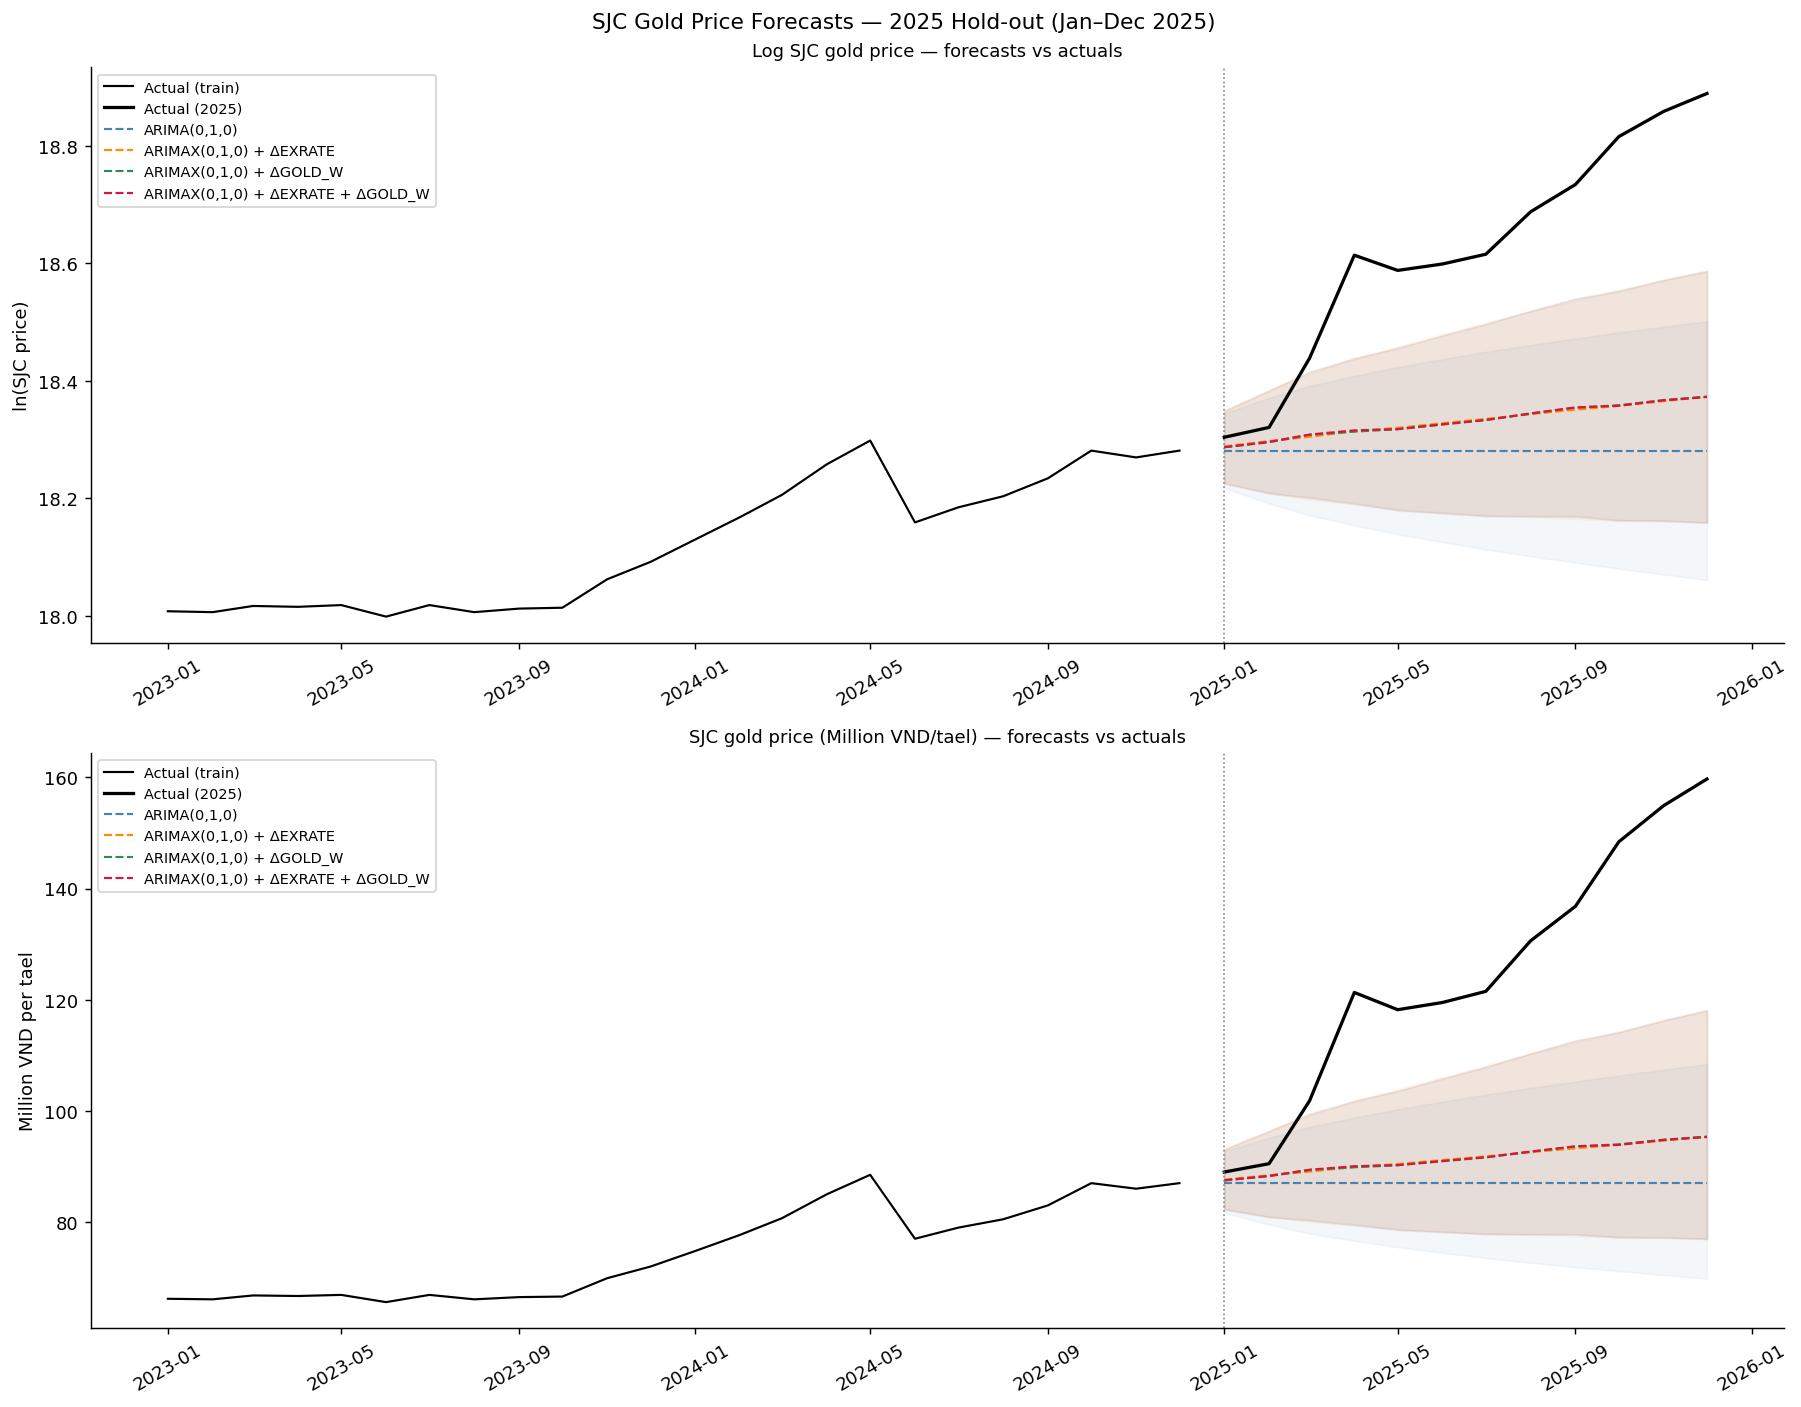

Plot saved: phase4_plots/forecasts_2025.png

MONTHLY FORECAST VS ACTUAL — 2025 (VND millions per tael)
         Actual  ARIMA(0,1,0)  ARIMAX(0,1,0)
date                                        
2025-01    89.0          87.0          87.49
2025-02    90.5          87.0          88.31
2025-03   101.8          87.0          89.41
2025-04   121.3          87.0          90.05
2025-05   118.2          87.0          90.24
2025-06   119.5          87.0          90.99
2025-07   121.5          87.0          91.65
2025-08   130.6          87.0          92.69
2025-09   136.8          87.0          93.63
2025-10   148.4          87.0          93.90
2025-11   154.9          87.0          94.77
2025-12   159.7          87.0          95.30


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle('SJC Gold Price Forecasts — 2025 Hold-out (Jan–Dec 2025)',
             fontsize=12, fontweight='500')

# ── Panel 1: Log levels ───────────────────────────────────────────────────────
ax = axes[0]
# Training actuals (last 24 months for context)
ax.plot(y_train.iloc[-24:].index, y_train.iloc[-24:],
        color='black', lw=1.2, label='Actual (train)', zorder=5)
# Test actuals
ax.plot(y_test.index, y_test,
        color='black', lw=1.8, ls='-', label='Actual (2025)', zorder=5)
# Forecasts
for name, d in forecasts.items():
    ax.plot(d['fc'].index, d['fc'],
            color=d['color'], lw=1.2, ls='--', label=d['label'], zorder=4)
    ax.fill_between(d['fc'].index, d['ci_lo'], d['ci_hi'],
                    color=d['color'], alpha=0.06)
ax.axvline(pd.Timestamp(TEST_START), color='gray', ls=':', lw=0.9)
ax.set_title('Log SJC gold price — forecasts vs actuals', fontsize=10)
ax.set_ylabel('ln(SJC price)')
ax.legend(fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)

# ── Panel 2: VND levels ───────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(y_train.iloc[-24:].index, np.exp(y_train.iloc[-24:])/1e6,
         color='black', lw=1.2, label='Actual (train)')
ax2.plot(y_test.index, np.exp(y_test)/1e6,
         color='black', lw=1.8, label='Actual (2025)')
for name, d in forecasts.items():
    ax2.plot(d['fc'].index, np.exp(d['fc'])/1e6,
             color=d['color'], lw=1.2, ls='--', label=d['label'])
    ax2.fill_between(d['fc'].index,
                     np.exp(d['ci_lo'])/1e6, np.exp(d['ci_hi'])/1e6,
                     color=d['color'], alpha=0.06)
ax2.axvline(pd.Timestamp(TEST_START), color='gray', ls=':', lw=0.9)
ax2.set_title('SJC gold price (Million VND/tael) — forecasts vs actuals', fontsize=10)
ax2.set_ylabel('Million VND per tael')
ax2.legend(fontsize=8, loc='upper left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'forecasts_2025.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: phase4_plots/forecasts_2025.png')
print()

# ── Monthly forecast table ────────────────────────────────────────────────────
print('MONTHLY FORECAST VS ACTUAL — 2025 (VND millions per tael)')
print('=' * 80)
fc_table = pd.DataFrame({'Actual': np.exp(y_test)/1e6})
for name, d in forecasts.items():
    fc_table[d['label'].split(')')[0]+')'] = np.exp(d['fc'])/1e6
fc_table = fc_table.round(2)
fc_table.index = fc_table.index.strftime('%Y-%m')
print(fc_table.to_string())


---
## Cell 10 · Results summary & export

In [20]:
print('PHASE 4 — COMPLETE RESULTS SUMMARY')
print('=' * 68)
print(f'Best ARIMA  : ARIMA({BEST_P},1,{BEST_Q}) (AIC={arima_res.aic:.3f})')
print(f'Train sample: {y_train.index[0].date()} → {y_train.index[-1].date()} (N={len(y_train)})')
print(f'Test sample : {y_test.index[0].date()} → {y_test.index[-1].date()} (N={len(y_test)})')
print()

print('MODEL COMPARISON (in-sample AIC):')
print(ic_df[['Model','AIC','BIC']].to_string(index=False))
print()

print('FORECAST ACCURACY (out-of-sample 2025):')
print(acc_df[['Model','RMSE_log','MAE_log','MAPE_log%',
              'RMSE_VND(M)','MAE_VND(M)','MAPE_VND%']].to_string(index=False))
print()

print('DIEBOLD-MARIANO TEST:')
print(dm_df.to_string(index=False))
print()

print('ECONOMIC INTERPRETATION')
print('=' * 68)
print()
print('1. Forecasting performance:')
best_fc = acc_df.iloc[0]
print(f'   Best model: {best_fc.Model}')
print(f'   MAPE = {best_fc["MAPE_VND%"]:.2f}% — average monthly forecast error')
print(f'   MAE  = {best_fc["MAE_VND(M)"]:.2f}M VND/tael — average absolute error')
print()
print('2. Exchange rate forecasting value (Research Question):')
if 'ARIMAX-EX' in forecasts:
    ex_row = acc_df[acc_df['Model'].str.contains('EXRATE')]
    if len(ex_row) > 0:
        ex_mape = ex_row.iloc[0]['MAPE_VND%']
        ar_mape = acc_df[acc_df['Model'].str.contains('ARIMA\(')].iloc[0]['MAPE_VND%']
        improvement = ar_mape - ex_mape
        print(f'   ARIMA MAPE   : {ar_mape:.2f}%')
        print(f'   ARIMAX-EX MAPE: {ex_mape:.2f}%')
        print(f'   Improvement  : {improvement:.2f} percentage points')
print()
print('3. EMH implication:')
dm_ex = dm_df[dm_df['Model'].str.contains('EXRATE')]
if len(dm_ex) > 0 and dm_ex.iloc[0]['p_value'] >= 0.05:
    print('   DM test is not significant — exchange rate information is')
    print('   already incorporated in gold prices (consistent with')
    print('   semi-strong form EMH for the Vietnamese gold market).')
elif len(dm_ex) > 0:
    print('   DM test is significant — exchange rate provides additional')
    print('   forecasting power beyond past gold prices (market inefficiency).')

# ── Export ────────────────────────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'phase4_results.xlsx')
with pd.ExcelWriter(out_path, engine='openpyxl') as w:
    arima_df.to_excel(w, sheet_name='arima_order_selection', index=False)
    ic_df.to_excel(   w, sheet_name='model_comparison',      index=False)
    acc_df.to_excel(  w, sheet_name='forecast_accuracy',     index=False)
    dm_df.to_excel(   w, sheet_name='diebold_mariano',       index=False)
    # Monthly forecasts
    fc_export = pd.DataFrame({'date': y_test.index,
                               'actual_log': y_test.values,
                               'actual_VND_M': np.exp(y_test.values)/1e6})
    for name, d in forecasts.items():
        fc_export[f'{name}_log'] = d['fc'].values
        fc_export[f'{name}_VND_M'] = np.exp(d['fc'].values)/1e6
    fc_export.to_excel(w, sheet_name='monthly_forecasts', index=False)

print(f'Exported: {os.path.abspath(out_path)}')
print('Sheets  : arima_order_selection · model_comparison · forecast_accuracy')
print('          diebold_mariano · monthly_forecasts')
print()
print('=' * 68)
print('PHASE 4 COMPLETE')
print('=' * 68)
print('All phases done. Proceed to Phase 5: manuscript writing.')


PHASE 4 — COMPLETE RESULTS SUMMARY
Best ARIMA  : ARIMA(0,1,0) (AIC=-476.448)
Train sample: 2015-01-01 → 2024-12-01 (N=120)
Test sample : 2025-01-01 → 2025-12-01 (N=12)

MODEL COMPARISON (in-sample AIC):
       Model      AIC      BIC
ARIMA(0,1,0) -481.316 -475.758
   ARIMAX-GW -474.999 -466.687
   ARIMAX-EX -474.655 -466.343
 ARIMAX-BOTH -473.405 -462.323

FORECAST ACCURACY (out-of-sample 2025):
                            Model  RMSE_log  MAE_log  MAPE_log%  RMSE_VND(M)  MAE_VND(M)  MAPE_VND%
ARIMAX(0,1,0) + ΔEXRATE + ΔGOLD_W  0.330636 0.290087     1.5495       38.359      32.814    24.2156
          ARIMAX(0,1,0) + ΔGOLD_W  0.330719 0.290317     1.5507       38.362      32.835    24.2356
          ARIMAX(0,1,0) + ΔEXRATE  0.331068 0.290319     1.5507       38.399      32.837    24.2271
                     ARIMA(0,1,0)  0.387319 0.340552     1.8191       43.473      37.350    27.6198

DIEBOLD-MARIANO TEST:
                            Model  DM_stat  p_value                      Decis